mtcarsMeanCarWise : 
 mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
dtype: float64
mtcarsStanderdDevCarWise : 
 mpg       6.026948
cyl       1.785922
disp    123.938694
hp       68.562868
drat      0.534679
dtype: float64
mtcarsVarienceDevCarWise : 
 mpg        36.324103
cyl         3.189516
disp    15360.799829
hp       4700.866935
drat        0.285881
dtype: float64
medianCarsFeatures : 
 mpg      19.200
cyl       6.000
disp    196.300
hp      123.000
drat      3.695
wt        3.325
qsec     17.710
vs        0.000
am        0.000
gear      4.000
carb      2.000
dtype: float64


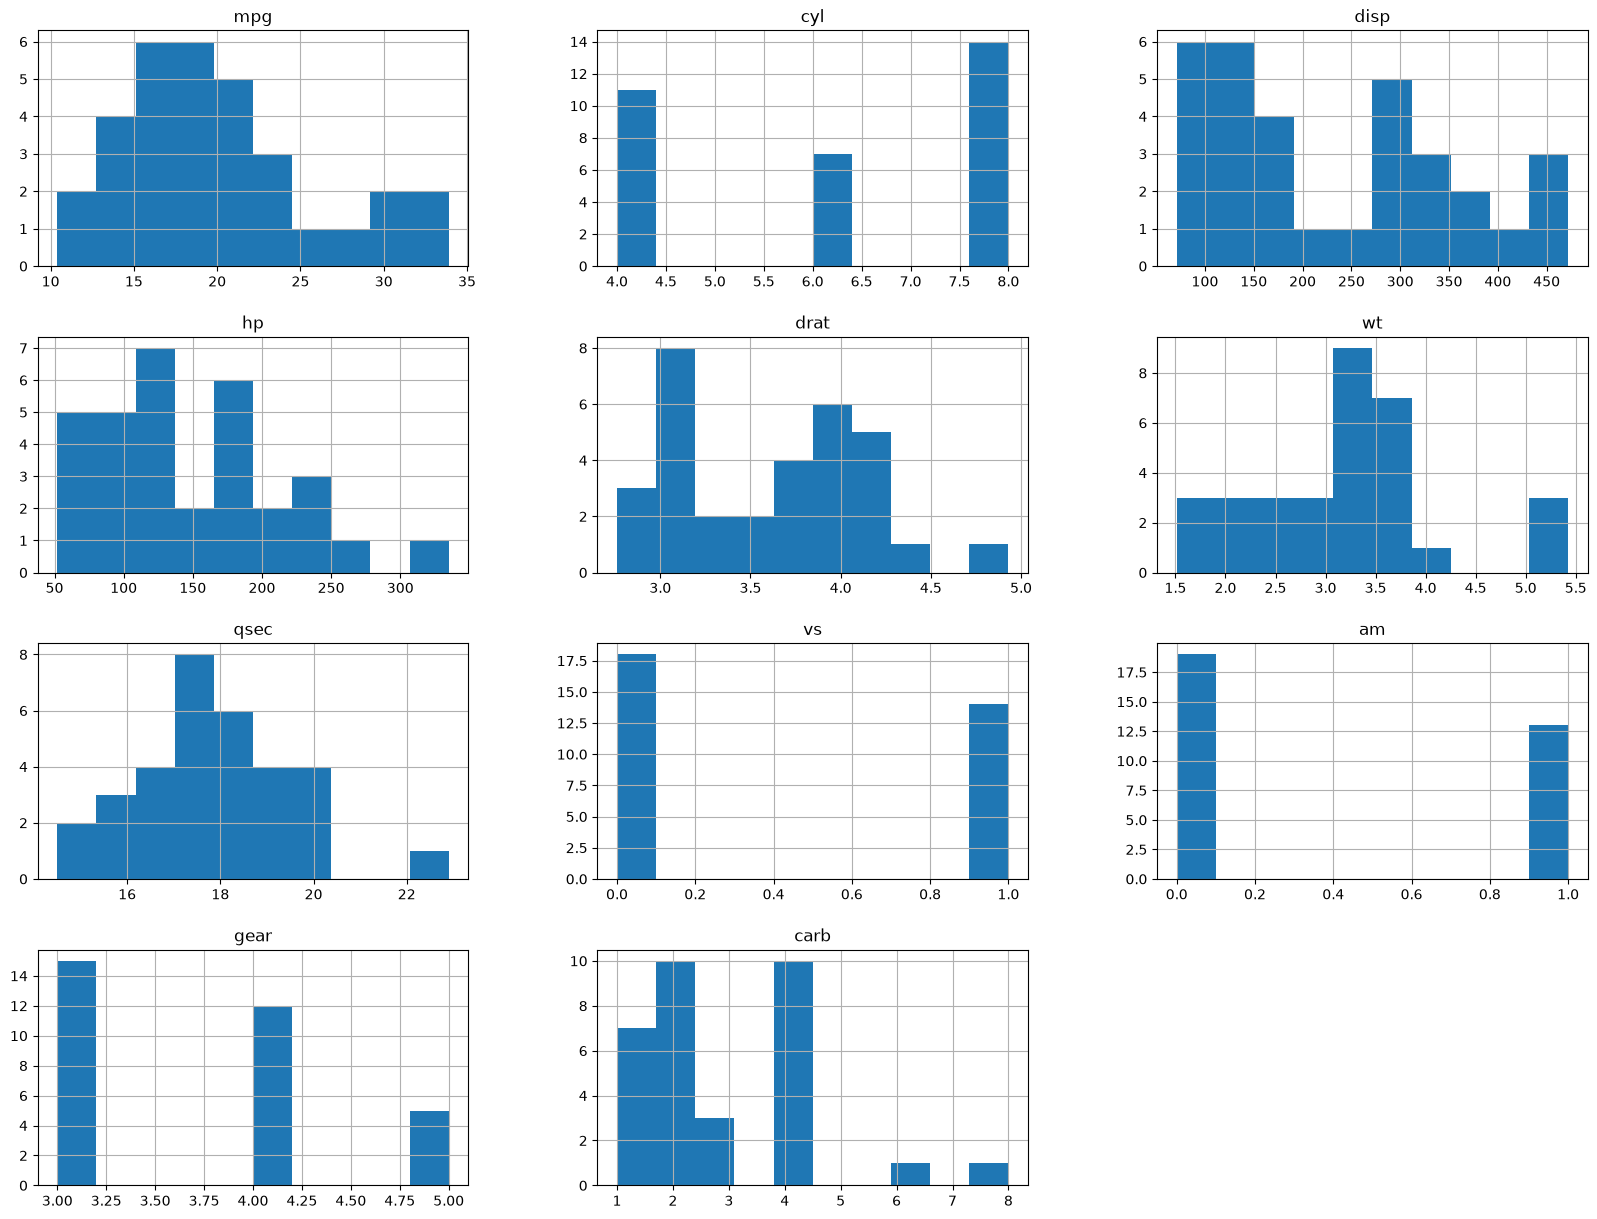

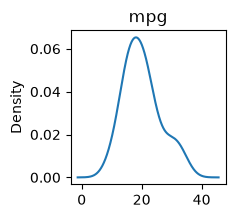

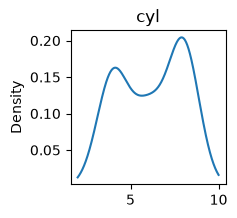

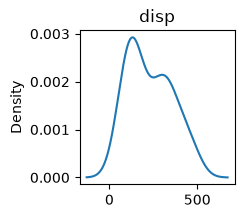

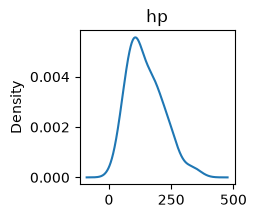

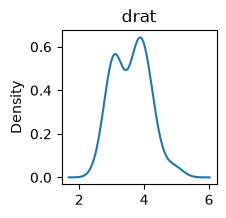

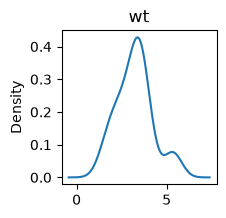

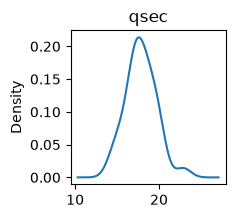

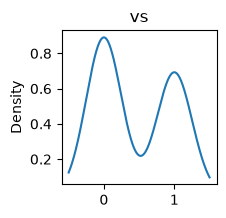

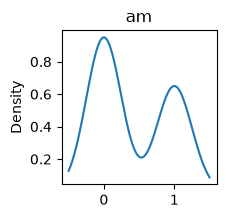

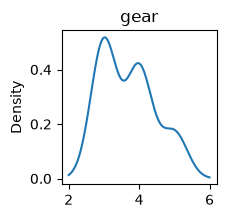

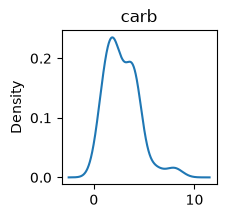

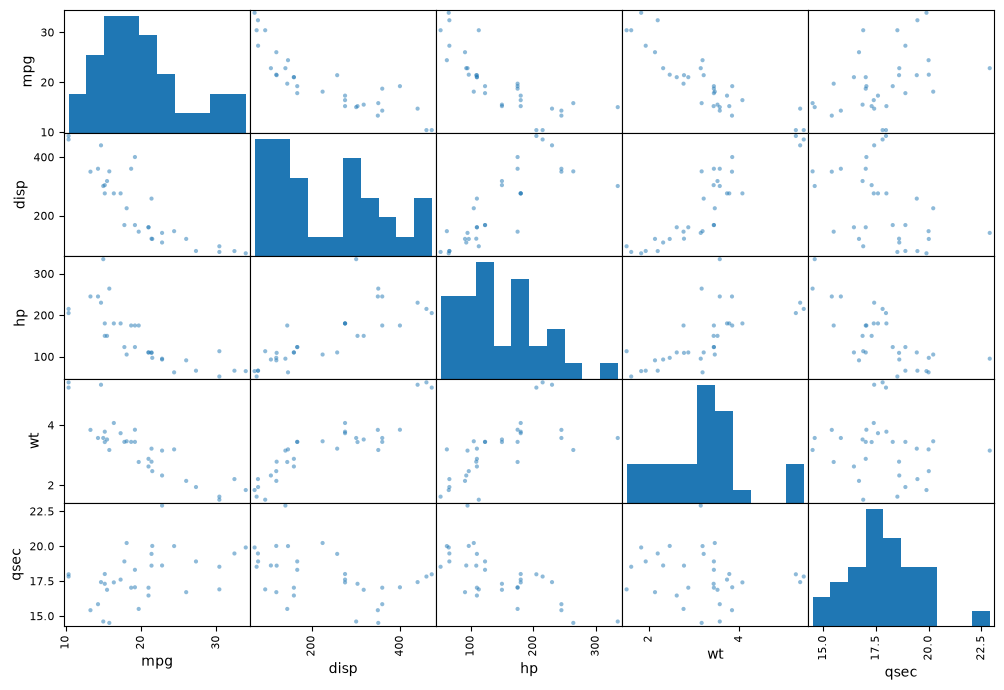

Skewness of columns:
 mpg     0.672377
cyl    -0.192261
disp    0.420233
hp      0.799407
drat    0.292780
wt      0.465916
qsec    0.406347
vs      0.264542
am      0.400809
gear    0.582309
carb    1.157091
dtype: float64
Describe se IQR: 7.375


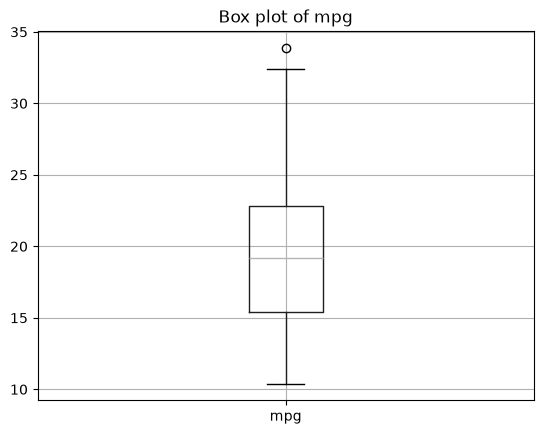

MPG Stats - Mean: 20.09, Std Dev: 6.03, Variance: 36.32


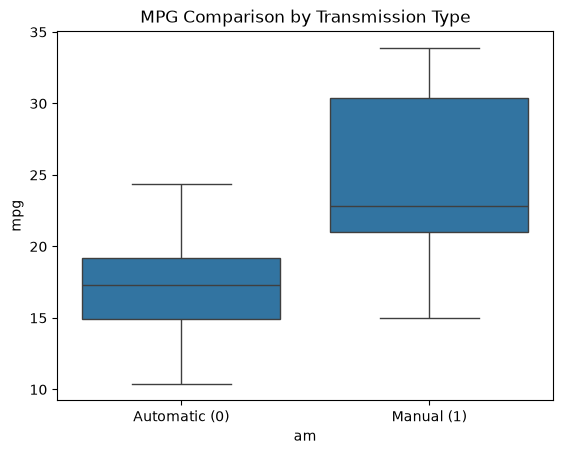

           mpg       cyl      disp        hp      drat        wt      qsec  \
mpg   1.000000 -0.852162 -0.847551 -0.776168  0.681172 -0.867659  0.418684   
cyl  -0.852162  1.000000  0.902033  0.832447 -0.699938  0.782496 -0.591242   
disp -0.847551  0.902033  1.000000  0.790949 -0.710214  0.887980 -0.433698   
hp   -0.776168  0.832447  0.790949  1.000000 -0.448759  0.658748 -0.708223   
drat  0.681172 -0.699938 -0.710214 -0.448759  1.000000 -0.712441  0.091205   
wt   -0.867659  0.782496  0.887980  0.658748 -0.712441  1.000000 -0.174716   
qsec  0.418684 -0.591242 -0.433698 -0.708223  0.091205 -0.174716  1.000000   
vs    0.664039 -0.810812 -0.710416 -0.723097  0.440278 -0.554916  0.744535   
am    0.599832 -0.522607 -0.591227 -0.243204  0.712711 -0.692495 -0.229861   
gear  0.480285 -0.492687 -0.555569 -0.125704  0.699610 -0.583287 -0.212682   
carb -0.550925  0.526988  0.394977  0.749812 -0.090790  0.427606 -0.656249   

            vs        am      gear      carb  
mpg   0.664039  

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from ggplot import mtcars
import statsmodels.api as sm

#mtcars.index = mtcars["name"]
# mtcars dataset ko statsmodels se load karne ka perfect tarika
mtcars = sm.datasets.get_rdataset("mtcars", "datasets").data

# Kyunki statsmodels mein car names pehle se hi index ban kar aate hain,
# isliye alag se mtcars.index karne ki zaroori nahi padegi!

#print("all : \n",mtcars)

column_mean = mtcars.mean(numeric_only=True)
#print("column_mean : \n",column_mean)

mtcarsMeanCarWise = mtcars.mean(axis = 0,numeric_only=True)
print("mtcarsMeanCarWise : \n",mtcarsMeanCarWise.head())
#attributes = ["Toyota Corolla"]
#mtcarsMeanCarWise1 = mtcars.mean(attributes)
#print("mtcarsMeanCarWise : \n",mtcarsMeanCarWise(rownames=))
#toyota_mean = mtcarsMeanCarWise.loc["Toyota Corolla"]
#print("Toyota Corolla ka Mean:", toyota_mean)

mtcarsStanderdDevCarWise = mtcars.std(axis = 0,numeric_only=True)
print("mtcarsStanderdDevCarWise : \n",mtcarsStanderdDevCarWise.head())

mtcarsVarienceDevCarWise = mtcars.var(axis = 0,numeric_only=True)
print("mtcarsVarienceDevCarWise : \n",mtcarsVarienceDevCarWise.head())

medianCarsFeatures = mtcars.median(axis = 0, numeric_only = True)
print("medianCarsFeatures : \n",medianCarsFeatures)

mtcars.hist(bins = 10, figsize = (20,15))
plt.show()

for i in mtcars.select_dtypes(include = ['number']):
    mtcars[i].plot(kind = "density" , figsize = (2,2))
    plt.title(i)
    plt.show()

# Sirf specific attributes ko filter karke scatter matrix banana
attributes = ["mpg", "disp", "hp", "wt", "qsec"]
pd.plotting.scatter_matrix(mtcars[attributes], figsize=(12, 8))

plt.show()

skewness = mtcars.skew(numeric_only=True)
print("Skewness of columns:\n", skewness)


# Pehle mpg column ki summary nikalenge
mpg_summary = mtcars['mpg'].describe()

# Summary se 75% (Q3) aur 25% (Q1) uthayenge
q3_desc = mpg_summary['75%']
q1_desc = mpg_summary['25%']

# Dono ko minus karke spread nikalenge
iqr_describe = q3_desc - q1_desc

print("Describe se IQR:", iqr_describe)

mtcars.boxplot(column='mpg')
plt.title("Box plot of mpg")
plt.show()

mpg_mean = mtcars['mpg'].mean()
mpg_std = mtcars['mpg'].std()
mpg_var = mtcars['mpg'].var()
print(f"MPG Stats - Mean: {mpg_mean:.2f}, Std Dev: {mpg_std:.2f}, Variance: {mpg_var:.2f}")

# 11. Extract subsets based on transmission (am: 0 = automatic, 1 = manual)
mtCarsAutomatic = mtcars[mtcars['am'] == 0]
mtCarsManual = mtcars[mtcars['am'] == 1]

# 12. Plotting box plot for 'mpg' grouped by transmission
import seaborn as sns # Boxplot visual clean banane ke liye seaborn use kar sakte hain
sns.boxplot(x='am', y='mpg', data=mtcars)
plt.xticks([0, 1], ['Automatic (0)', 'Manual (1)'])
plt.title("MPG Comparison by Transmission Type")
plt.show()


# Poore dataset ka correlation matrix nikalna
correlation_matrix = mtcars.corr(numeric_only=True)

# Output ko dekhne ke liye print karenge
print(correlation_matrix)

In [29]:
!pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ----- --------------------------------- 41.0/294.9 kB 960.0 kB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 3.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
